## Import Required libraries 

In [5]:
## Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    silhouette_score,
    confusion_matrix,
    accuracy_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from scipy.spatial.distance import euclidean

## Load Dataset

In [6]:
df = pd.read_csv("C:/Users/saura/OneDrive/Desktop/capstone/Crop_Advisory_system-main/Data/Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## Feature Selection

In [7]:
X = df.drop("label", axis=1)
y = df["label"]

## TRAIN-TEST SPLIT (80-20)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

## Feature Scaling

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

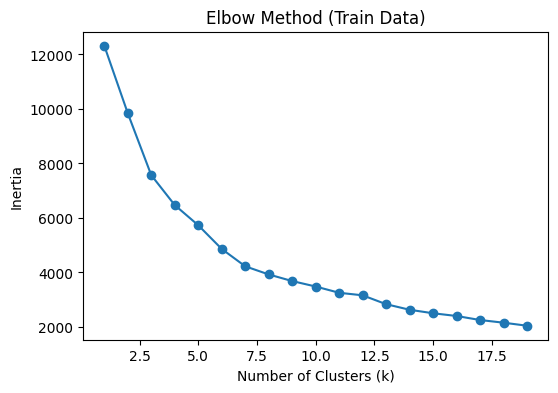

In [10]:
# ==============================
# ELBOW METHOD (ON TRAIN DATA)
# ==============================

inertia = []

for k in range(1, 20):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_scaled)
    inertia.append(kmeans.inertia_)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(range(1,20), inertia, marker='o')
plt.title("Elbow Method (Train Data)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

## SILHOUETTE SCORE

In [11]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_train_scaled)
    
    score = silhouette_score(X_train_scaled, labels)
    sil_scores.append(score)
    
    print(f"K={k}, Silhouette Score={round(score,4)}")

K=2, Silhouette Score=0.3268
K=3, Silhouette Score=0.2508
K=4, Silhouette Score=0.2539
K=5, Silhouette Score=0.261
K=6, Silhouette Score=0.3081
K=7, Silhouette Score=0.3306
K=8, Silhouette Score=0.3361
K=9, Silhouette Score=0.3227
K=10, Silhouette Score=0.3138
K=11, Silhouette Score=0.3149
K=12, Silhouette Score=0.3115
K=13, Silhouette Score=0.3183
K=14, Silhouette Score=0.3227


### Best K

In [12]:
# Best K
best_k = range(2, 15)[np.argmax(sil_scores)]
print("Best K based on Silhouette:", best_k)


Best K based on Silhouette: 8


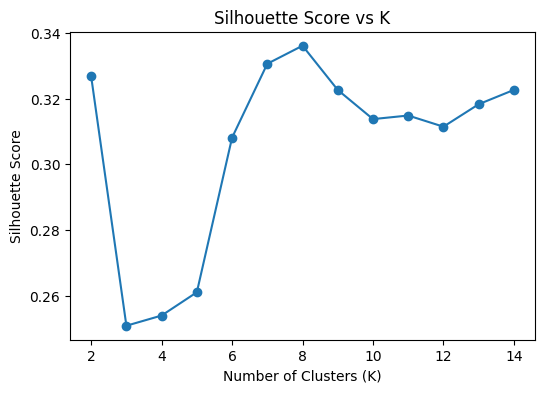

In [13]:
plt.figure(figsize=(6,4))
plt.plot(range(2,15), sil_scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

## TRAIN KMEANS (ONLY ON TRAIN)

In [14]:
kmeans = KMeans(n_clusters=12, random_state=42)
kmeans.fit(X_train_scaled)

centroids = kmeans.cluster_centers_

## CREATE TRAIN DF (FOR PROPORTIONS)

In [15]:

train_df = X_train.copy()
train_df["label"] = y_train.values
train_df["Cluster"] = kmeans.labels_

train_viz_df = train_df.copy()

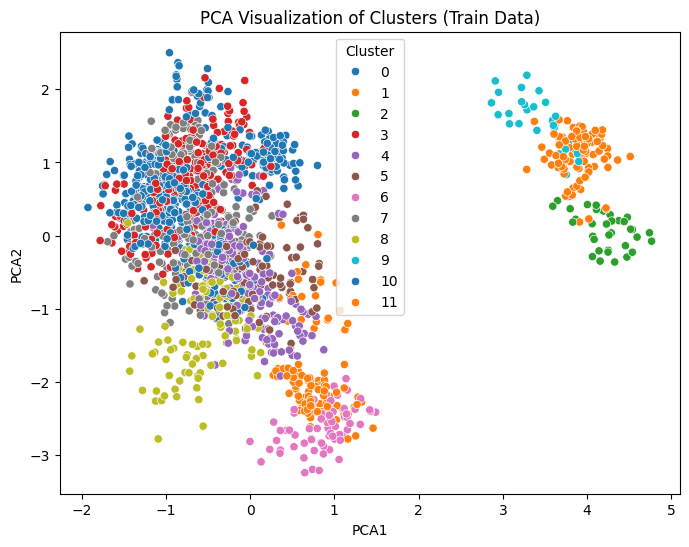

In [16]:
# ==============================
# 10. PCA VISUALIZATION
# ==============================
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_train_scaled)

train_viz_df["PCA1"] = pca_components[:, 0]
train_viz_df["PCA2"] = pca_components[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=train_viz_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="tab10"
)
plt.title("PCA Visualization of Clusters (Train Data)")
plt.show()

In [17]:

# ==============================
# 11. CLUSTER ANALYSIS
# ==============================

# Number of samples
print("\nSamples in each cluster:")
print(train_viz_df["Cluster"].value_counts().sort_index())

# Unique crops
print("\nUnique crops per cluster:")
print(train_viz_df.groupby("Cluster")["label"].nunique())

# Crops per cluster
print("\nCrops in each cluster:")
for i in sorted(train_viz_df["Cluster"].unique()):
    crops = train_viz_df[train_viz_df["Cluster"] == i]["label"].unique()
    print(f"\nCluster {i}: {crops}")

# Distribution table
print("\nCluster vs Crop Distribution:")
cluster_crop_table = pd.crosstab(
    train_viz_df["Cluster"],
    train_viz_df["label"]
)
print(cluster_crop_table)


Samples in each cluster:
Cluster
0     422
1     109
2      35
3     239
4     221
5     138
6      69
7     218
8     119
9      27
10     62
11    101
Name: count, dtype: int64

Unique crops per cluster:
Cluster
0     7
1     3
2     1
3     5
4     9
5     3
6     1
7     3
8     6
9     1
10    2
11    2
Name: label, dtype: int64

Crops in each cluster:

Cluster 0: <ArrowStringArray>
['banana', 'maize', 'cotton', 'coffee', 'muskmelon', 'papaya', 'watermelon']
Length: 7, dtype: str

Cluster 1: <ArrowStringArray>
['kidneybeans', 'pigeonpeas', 'chickpea']
Length: 3, dtype: str

Cluster 2: <ArrowStringArray>
['grapes']
Length: 1, dtype: str

Cluster 3: <ArrowStringArray>
['jute', 'rice', 'pigeonpeas', 'coffee', 'papaya']
Length: 5, dtype: str

Cluster 4: <ArrowStringArray>
[ 'blackgram',     'lentil',   'mungbean',      'mango',     'papaya',
  'mothbeans',      'maize',     'orange', 'pigeonpeas']
Length: 9, dtype: str

Cluster 5: <ArrowStringArray>
['mango', 'pigeonpeas', 'mothbeans

## PREDICTION ON TEST DATA

In [18]:

predictions = []

cluster_counts = train_df["Cluster"].value_counts()

for i in range(len(X_test_scaled)):
    
    sample = X_test_scaled[i]
    
    # Step 1: Compute distance to all centroids
    distances = []
    for j, centroid in enumerate(centroids):
        d = euclidean(sample, centroid)
        distances.append((j, d))
    
    # Step 2: Get top 3 nearest clusters
    distances_sorted = sorted(distances, key=lambda x: x[1])
    top_clusters = [c[0] for c in distances_sorted[:3]]
    
    total_samples = cluster_counts[top_clusters].sum()
    
    scores = {}
    
    # Step 3: Apply formula
    for cluster, dist in distances_sorted[:3]:
        
        weight = cluster_counts[cluster] / total_samples
        
        cluster_data = train_df[train_df["Cluster"] == cluster]
        proportions = cluster_data["label"].value_counts(normalize=True)
        
        for crop, prop in proportions.items():
            
            score = (1 / (dist + 1e-6)) * prop * weight
            
            if crop not in scores:
                scores[crop] = 0
            
            scores[crop] += score
    
    # Step 4: Get best prediction
    best_crop = max(scores, key=scores.get)
    
    predictions.append(best_crop)

## RESULT DATAFRAME

In [19]:

result_df = pd.DataFrame({
    "Actual Crop": y_test.values,
    "Predicted Crop": predictions
})

print("\nSample Predictions:")
print(result_df.head())



Sample Predictions:
  Actual Crop Predicted Crop
0   muskmelon         cotton
1  watermelon         cotton
2      papaya         papaya
3      papaya         papaya
4       apple          apple


## ACCURACY

In [20]:

accuracy = accuracy_score(result_df["Actual Crop"], result_df["Predicted Crop"])

print("\nFinal Recommendation Accuracy:", round(accuracy, 4))


Final Recommendation Accuracy: 0.4364


In [21]:

# ==============================
# 15. TOP-3 ACCURACY (IMPORTANT)
# ==============================
top3_correct = 0

for i in range(len(X_test_scaled)):
    
    sample = X_test_scaled[i]
    
    distances = [(j, euclidean(sample, c)) for j, c in enumerate(centroids)]
    distances_sorted = sorted(distances, key=lambda x: x[1])
    
    scores = {}
    
    for cluster, dist in distances_sorted[:3]:
        
        weight = cluster_counts[cluster] / cluster_counts.sum()
        
        cluster_data = train_viz_df[train_viz_df["Cluster"] == cluster]
        proportions = cluster_data["label"].value_counts(normalize=True)
        
        for crop, prop in proportions.items():
            score = (1 / (dist + 1e-6)) * prop * weight
            
            if crop not in scores:
                scores[crop] = 0
                
            scores[crop] += score
    
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top3_preds = [crop for crop, _ in sorted_scores[:3]]
    
    if y_test.values[i] in top3_preds:
        top3_correct += 1

top3_accuracy = top3_correct / len(y_test)

print("Top-3 Accuracy:", round(top3_accuracy, 4))

Top-3 Accuracy: 0.7977



## Conclusion

This project demonstrates how unsupervised learning techniques (where the model finds patterns without predefined labels) can be effectively extended to solve a real-world recommendation problem. By applying KMeans clustering on soil and environmental features, we were able to group similar agricultural conditions and analyze how different crops are distributed within each group (cluster).

Unlike traditional approaches that rely on direct classification, this system introduces a hybrid distance-based scoring mechanism, where recommendations are generated using:

    - Proximity to cluster centroids
      (i.e., how close the input soil conditions are to the center of a cluster — closer means more similar conditions)
    - Crop distribution within clusters
      (i.e., which crops are most commonly found in that cluster and their relative proportions)
    - Relative importance of clusters
      (i.e., how significant a cluster is based on the number of data points it contains)

This approach allows the model to provide ranked crop recommendations rather than a single rigid prediction, 
making it more flexible and closer to real-world decision-making where multiple crop options are possible.

We also observed an important trade-off:

    - Lower number of clusters improves cluster separation (Silhouette Score)
      (i.e., how well-defined and distinct the clusters are)
    - Higher number of clusters improves prediction accuracy
      (i.e., better alignment with actual crop labels due to more detailed grouping)

This highlights the difference between clustering quality (how well data is grouped) and prediction performance 
(how well the system matches real outcomes), and emphasizes the need to choose model parameters based on the final objective.

Overall, the project successfully transforms clustering into a data-driven decision support system, demonstrating how machine learning can assist in agricultural planning by providing interpretable (easy to understand) and meaningful insights.